In [2]:
import pandas as pd
import glob
import re

# 1. Define the cleaning function
def clean_and_load(filename):
    df = pd.read_csv(filename)
    
    # Clean Price: Remove '$' and ',' and convert to number
    # This creates 'Price_num' for EVERY file
    if 'Price' in df.columns:
        clean_price = df['Price'].astype(str).str.replace(r'[$,]', '', regex=True)
        df['Price_num'] = pd.to_numeric(clean_price, errors='coerce')

    # Clean Date: Create 'year' and 'Month'
    if 'Sold Date' in df.columns:
        df['Sold Date'] = pd.to_datetime(df['Sold Date'], errors='coerce')
        df['year'] = df['Sold Date'].dt.year
        df['Month'] = df['Sold Date'].dt.month
        
    return df

# 2. Apply this to all files
csv_files = glob.glob('*.csv')
all_data = [clean_and_load(f) for f in csv_files]

# 3. Combine
final_df = pd.concat(all_data, ignore_index=True)

# 4. Check the result
print(f"Total Rows: {len(final_df)}")
print(f"Rows with valid Price_num: {final_df['Price_num'].notnull().sum()}")
final_df.head()

Total Rows: 35584
Rows with valid Price_num: 35584


,Page,Title,Price,Sold Date,Link,Image Link,Storage,Condition,PartsOnly,Model,...,Galaxy_S23Plus,Galaxy_S24Plus,Galaxy_S25Plus,Pixel_6_Pro,Pixel_7_Pro,Pixel_8_Pro,Pixel_9_Pro,Pixel_9_Pro_XL,Pixel_10_Pro,Pixel_10_Pro_XL
0,1,Google Pixel 6 5G UW 256GB G9S9B Verizon/Unloc...,$195.49,2025-07-23,https://www.ebay.com/itm/267327711422,https://i.ebayimg.com/images/g/9FQAAOSwxOBicD9...,256 GB,Excellent,False,Pixel 6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Google Pixel 6 128GB GB7N6 CDMA/GSM Unlocked S...,$161.49,2025-10-18,https://www.ebay.com/itm/267187173848,https://i.ebayimg.com/images/g/9FQAAOSwxOBicD9...,128 GB,Excellent,False,Pixel 6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,"Unlocked Google Pixel 6 GA02910-US 6.4"" 128GB ...",$129.99,2025-10-17,https://www.ebay.com/itm/197701916743,https://i.ebayimg.com/images/g/eO4AAOSwck9hyhr...,128 GB,Unknown,False,Pixel 6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,Google Pixel 6 5G GB7N6 Unlocked AT&T T-Mobile...,$135.99,2025-10-17,https://www.ebay.com/itm/186382972121,https://i.ebayimg.com/images/g/9UwAAOSwRVBizcu...,128 GB,Very Good,False,Pixel 6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,Google Pixel 6 5G GB7N6 Unlocked AT&T T-Mobile...,$126.99,2025-10-16,https://www.ebay.com/itm/204733253931,https://i.ebayimg.com/images/g/9UwAAOSwRVBizcu...,128 GB,Good,False,Pixel 6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
import pandas as pd

# 1. Load your current combined file
df = pd.read_csv('All_Phones_Combined.csv')

# 2. Fix the "Price" column (Remove '$' and convert to number)
# This fills in the missing "Price_num" for iPhones, Pixels, etc.
df['Price_num'] = df['Price'].astype(str).str.replace(r'[$,]', '', regex=True)
df['Price_num'] = pd.to_numeric(df['Price_num'], errors='coerce')

# 3. Fix the "Date" column (Extract Year and Month)
df['Sold Date'] = pd.to_datetime(df['Sold Date'], errors='coerce')
df['year'] = df['Sold Date'].dt.year
df['Month'] = df['Sold Date'].dt.month_name()

# 4. Save the fixed file
df.to_csv('All_Phones_Fixed.csv', index=False)

# 5. Verify the fix
print(f"Total Rows: {len(df)}")
print(f"Valid Prices: {df['Price_num'].notnull().sum()}")
df.head()

Total Rows: 4448
Valid Prices: 4448


,Page,Title,Price,Sold Date,Link,Image Link,Storage,Condition,PartsOnly,Model,...,Galaxy_S23Plus,Galaxy_S24Plus,Galaxy_S25Plus,Pixel_6_Pro,Pixel_7_Pro,Pixel_8_Pro,Pixel_9_Pro,Pixel_9_Pro_XL,Pixel_10_Pro,Pixel_10_Pro_XL
0,1,Google Pixel 6 5G UW 256GB G9S9B Verizon/Unloc...,$195.49,2025-07-23,https://www.ebay.com/itm/267327711422,https://i.ebayimg.com/images/g/9FQAAOSwxOBicD9...,256 GB,Excellent,False,Pixel 6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Google Pixel 6 128GB GB7N6 CDMA/GSM Unlocked S...,$161.49,2025-10-18,https://www.ebay.com/itm/267187173848,https://i.ebayimg.com/images/g/9FQAAOSwxOBicD9...,128 GB,Excellent,False,Pixel 6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,"Unlocked Google Pixel 6 GA02910-US 6.4"" 128GB ...",$129.99,2025-10-17,https://www.ebay.com/itm/197701916743,https://i.ebayimg.com/images/g/eO4AAOSwck9hyhr...,128 GB,Unknown,False,Pixel 6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,Google Pixel 6 5G GB7N6 Unlocked AT&T T-Mobile...,$135.99,2025-10-17,https://www.ebay.com/itm/186382972121,https://i.ebayimg.com/images/g/9UwAAOSwRVBizcu...,128 GB,Very Good,False,Pixel 6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,Google Pixel 6 5G GB7N6 Unlocked AT&T T-Mobile...,$126.99,2025-10-16,https://www.ebay.com/itm/204733253931,https://i.ebayimg.com/images/g/9UwAAOSwRVBizcu...,128 GB,Good,False,Pixel 6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


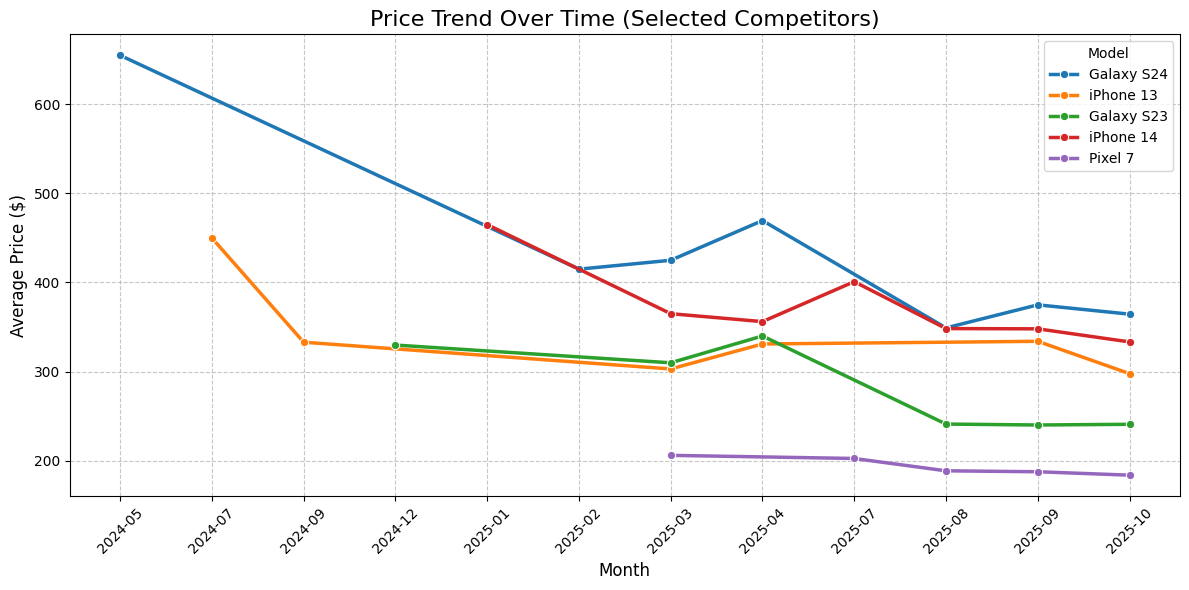

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv('All_Phones_Fixed.csv')

# 2. Ensure Date format is correct
df['Sold Date'] = pd.to_datetime(df['Sold Date'])

# 3. Create a "Month-Year" column for grouping (e.g., "2025-06")
df['Month_Year'] = df['Sold Date'].dt.to_period('M')

# 4. Filter for specific competitors to keep the chart clean
# You can add or remove models here
target_models = ['iPhone 13', 'Galaxy S23', 'Pixel 7', 'iPhone 14', 'Galaxy S24']
df_trend = df[df['Model'].isin(target_models)]

# 5. Calculate average price per month for each model
monthly_avg = df_trend.groupby(['Month_Year', 'Model'])['Price_num'].mean().reset_index()
monthly_avg['Month_Year'] = monthly_avg['Month_Year'].astype(str) # Convert to string for plotting

# 6. Generate the Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_avg, x='Month_Year', y='Price_num', hue='Model', marker='o', linewidth=2.5)

# Formatting
plt.title('Price Trend Over Time (Selected Competitors)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()

# 7. Save the figure
plt.savefig('price_trend_time.png', dpi=300)
plt.show()

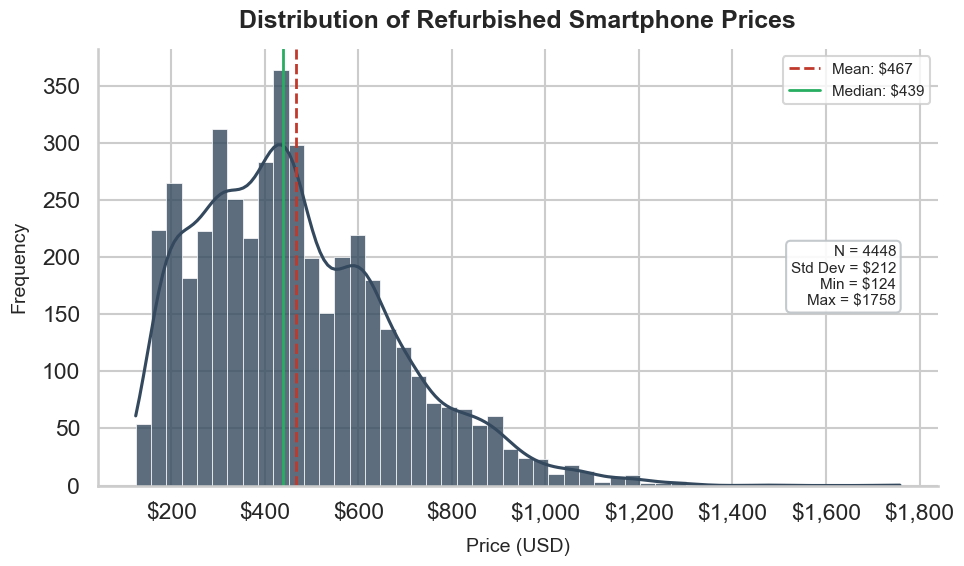

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import os

# 1. Load data
df = pd.read_csv('All_Phones_Fixed.csv')
df = df.dropna(subset=['Price_num'])

# 2. Set a professional theme (Whitegrid is best for printed reports)
sns.set_theme(style="whitegrid", context="talk")

# 3. Initialize Figure
plt.figure(figsize=(10, 6))

# 4. Create Histogram
# Using a deep slate blue for professionalism
ax = sns.histplot(
    df['Price_num'], 
    bins=50, 
    kde=True, 
    color="#34495e",       
    edgecolor="white",     
    linewidth=0.5,
    alpha=0.8              
)

# 5. Add Mean and Median Lines
mean_val = df['Price_num'].mean()
median_val = df['Price_num'].median()

plt.axvline(mean_val, color='#c0392b', linestyle='--', linewidth=2, label=f'Mean: ${mean_val:.0f}')
plt.axvline(median_val, color='#27ae60', linestyle='-', linewidth=2, label=f'Median: ${median_val:.0f}')

# 6. Formatting & Labels
plt.title('Distribution of Refurbished Smartphone Prices', fontsize=18, weight='bold', pad=15)
plt.xlabel('Price (USD)', fontsize=14, labelpad=10)
plt.ylabel('Frequency', fontsize=14, labelpad=10)

# Format X-axis with Dollar Signs
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# Remove top and right spines
sns.despine()

# 7. Add Legend & Summary Box
plt.legend(loc='upper right', frameon=True, fontsize=11)

# Statistical Summary Box
stats_text = (
    f"N = {len(df)}\n"
    f"Std Dev = ${df['Price_num'].std():.0f}\n"
    f"Min = ${df['Price_num'].min():.0f}\n"
    f"Max = ${df['Price_num'].max():.0f}"
)
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#bdc3c7')
ax.text(0.95, 0.55, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()

# 8. Save
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/enhanced_price_histogram.png', dpi=300)
plt.show()

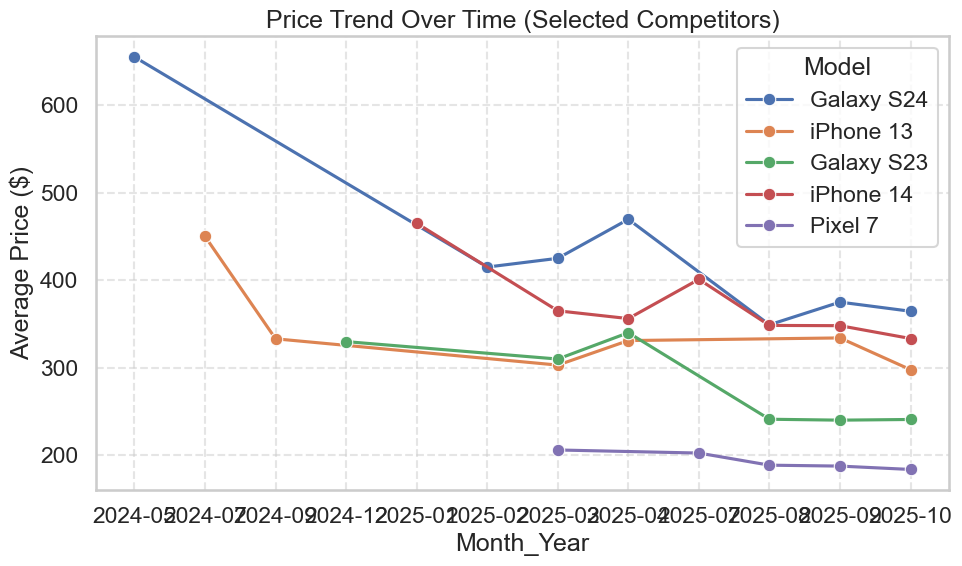

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv('All_Phones_Fixed.csv')
df['Sold Date'] = pd.to_datetime(df['Sold Date'])
df['Month_Year'] = df['Sold Date'].dt.to_period('M').astype(str)

# 2. Select Models
target_models = ['iPhone 13', 'Galaxy S23', 'Pixel 7', 'iPhone 14', 'Galaxy S24']
df_trend = df[df['Model'].isin(target_models)]

# 3. Aggregate
monthly_avg = df_trend.groupby(['Month_Year', 'Model'])['Price_num'].mean().reset_index()

# 4. Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_avg, x='Month_Year', y='Price_num', hue='Model', marker='o')
plt.title('Price Trend Over Time (Selected Competitors)')
plt.ylabel('Average Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 5. Save exactly as referenced in your LaTeX
plt.savefig('figures/price_trend_time.png', dpi=300)
plt.show()